In [144]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [145]:
df = pd.read_csv("spx_eod_202301.txt")
pd.set_option('display.max_columns', None)
df = df.sample(500)
df.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
128081,1674853200,2023-01-27 16:00,2023-01-27,16.0,4070.02,2024-02-16,1708117200,385.0,0.99062,0.00000,0.00000,-0.14935,20.07740,0.000440,,0.00,10 x 10,2113.2,2136.2,2000.0,11.9,12.7,210 x 60,13.66,-0.01817,0.00005,1.87860,-0.08481,-0.89055,0.386440,1.000000,2070.0,0.509
51926,1673557200,2023-01-12 16:00,2023-01-12,16.0,3982.87,2023-11-17,1700254800,309.0,0.37863,0.00059,13.88576,-0.53069,11.51519,0.174710,500.000000,126.60,37 x 39,154.0,156.0,4375.0,418.2,422.0,50 x 50,0.00,-0.76170,0.00096,9.86631,-0.12272,-9.68062,0.156190,,392.1,0.098
62003,1673989200,2023-01-17 16:00,2023-01-17,16.0,3990.40,2023-01-30,1675112400,13.0,0.90742,0.00124,1.27946,-1.05865,1.29824,0.165450,1.000000,142.36,30 x 97,168.8,172.2,3830.0,5.9,6.1,136 x 58,6.60,-0.09572,0.00130,1.32619,-0.77193,-0.14571,0.169540,2.000000,160.4,0.040
114524,1674766800,2023-01-26 16:00,2023-01-26,16.0,4060.18,2023-02-03,1675458000,8.0,0.88579,0.00133,1.19144,-1.39401,0.49915,0.252760,2.000000,156.34,100 x 100,184.3,188.6,3880.0,6.1,6.2,61 x 88,6.50,-0.09366,0.00123,1.05477,-1.33911,-0.09291,0.219950,125.000000,180.2,0.044
143401,1675198800,2023-01-31 16:00,2023-01-31,16.0,4077.16,2024-02-16,1708117200,381.0,0.67918,0.00045,14.64334,-0.60583,23.87863,0.198670,,0.00,14 x 14,485.6,490.3,3925.0,202.5,204.9,38 x 20,0.00,-0.33631,0.00050,14.85257,-0.27250,-12.36711,0.204850,,152.2,0.037


In [146]:
# drops columns that we may not need
df = df.drop(columns=["[QUOTE_UNIXTIME]", " [QUOTE_READTIME]", " [QUOTE_DATE]", " [EXPIRE_DATE]", " [EXPIRE_UNIX]"])

In [147]:
# rename for easier use in future
df = df.rename(columns={
    ' [QUOTE_TIME_HOURS]' : "Quote_Time_Hours",
    ' [UNDERLYING_LAST]' : "Underlying_Last",
    ' [DTE]' : "DTE", 
    ' [C_DELTA]' : "C_Delta",
    ' [C_GAMMA]' : "C_Gamma", 
    ' [C_VEGA]' : "C_Vega", 
    ' [C_THETA]' : "C_Theta",
    ' [C_RHO]' : "C_Rho", 
    ' [C_IV]' : "C_IV",
    ' [C_VOLUME]' : "C_Volume",
    ' [C_LAST]' : "C_Last", 
    ' [C_SIZE]' : "C_Size", 
    ' [C_BID]' : "C_Bid", 
    ' [C_ASK]' : "C_Ask",
    ' [STRIKE]' : "Strike", 
    ' [P_BID]' : "P_Bid",
    ' [P_ASK]' : "P_Ask",
    ' [P_SIZE]' : "P_Size", 
    ' [P_LAST]' : "P_Last",
    ' [P_DELTA]' : "P_Delta", 
    ' [P_GAMMA]' : "P_Gamma", 
    ' [P_VEGA]' : "P_Vega", 
    ' [P_THETA]' : "P_Theta", 
    ' [P_RHO]' : "P_Rho",
    ' [P_IV]' : "P_IV", 
    ' [P_VOLUME]' : "P_Volume", 
    ' [STRIKE_DISTANCE]' : "Strike_Distance",
    ' [STRIKE_DISTANCE_PCT]' : "Strike_Distance_PCT"
})


In [148]:
df = df.drop(columns=["C_Delta", "C_Gamma", "C_Vega", "C_Theta", "C_Rho", "P_Delta", "P_Gamma", "P_Vega", "P_Theta", "P_Rho"])

In [149]:
# turn " " in implied volatility columns into missing values and then drop
df["P_IV"] = df["P_IV"].replace(" ", np.nan)
df["C_IV"] = df["C_IV"].replace(" ", np.nan)
df = df.dropna(subset=["C_IV", "P_IV"])


In [150]:
# convert string into float
df["P_IV"] = df["P_IV"].astype(float)
df["C_IV"] = df["C_IV"].astype(float)

In [151]:
# create new columns, separate the size into bid and ask, convert to int
df["C_Bid_Size"] = df["C_Size"].str.split("x").str.get(0).astype(float)
df["C_Ask_Size"] = df["C_Size"].str.split("x").str.get(1).astype(float)
df["P_Bid_Size"] = df["P_Size"].str.split("x").str.get(0).astype(float)
df["P_Ask_Size"] = df["P_Size"].str.split("x").str.get(1).astype(float)

In [152]:
# since new columns were made we can drop original C_Size and P_Size
df = df.drop(columns = ["C_Size", "P_Size"])

In [153]:
df["C_Mid_Price"] = (df["C_Bid"] + df["C_Ask"]) / 2 
df["P_Mid_Price"] = (df["P_Bid"] + df["P_Ask"]) / 2 

In [154]:
# replace missing with zero and convert to float value 
df["C_Volume"] = df["C_Volume"].replace(" ", 0)
df["P_Volume"] = df["P_Volume"].replace(" ", 0)
df["C_Volume"] = df["C_Volume"].astype(float)
df["P_Volume"] = df["P_Volume"].astype(float)

In [155]:
call_X = df[["Quote_Time_Hours", "Underlying_Last", "DTE", "C_Volume", "C_Mid_Price", "Strike", "C_Bid_Size", "C_Ask_Size", "Strike_Distance", "Strike_Distance_PCT"]]
call_y = df["C_IV"]
call_X_train, call_X_test, call_y_train, call_y_test = train_test_split(
    call_X,
    call_y,
    test_size=0.25,
    random_state=42
)
call_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
call_rf.fit(call_X_train, call_y_train)
call_y_test_pred = call_rf.predict(call_X_test)
df["Predicted_C_IV"] = call_rf.predict(call_X)
df
print("MAE:", mean_absolute_error(call_y_test, call_y_test_pred))
print("R²:", r2_score(call_y_test, call_y_test_pred))

MAE: 0.12761381170212766
R²: 0.22482720162313752


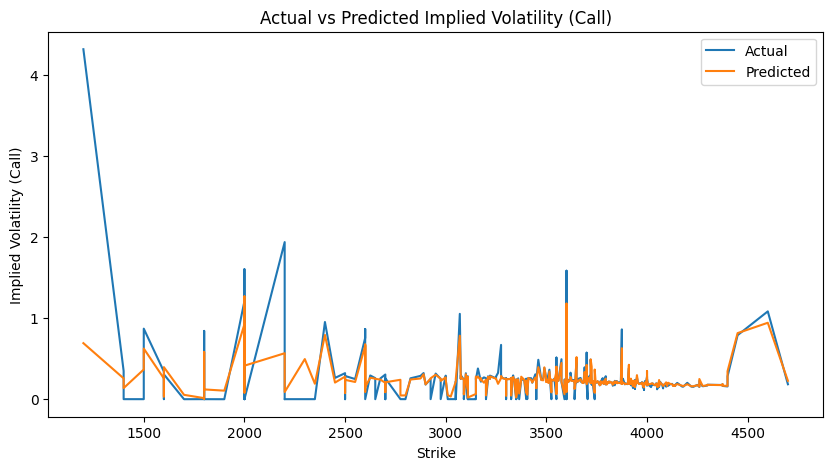

In [156]:
df_sorted = df.sort_values("Strike")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["Strike"], df_sorted["C_IV"], label="Actual")
plt.plot(df_sorted["Strike"], df_sorted["Predicted_C_IV"], label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.legend()
plt.show()

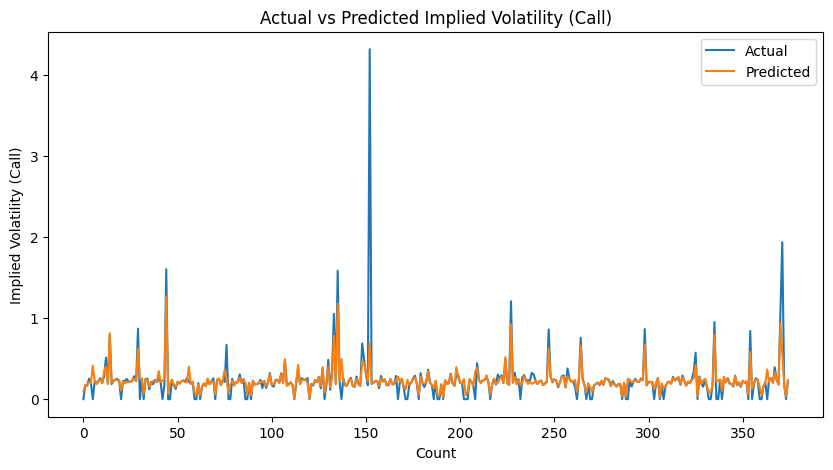

In [157]:
x = range(len(df))
plt.figure(figsize=(10, 5))
plt.plot(x, df["C_IV"], label="Actual")
plt.plot(x, df["Predicted_C_IV"], label="Predicted")
plt.xlabel("Count")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.legend()
plt.show()

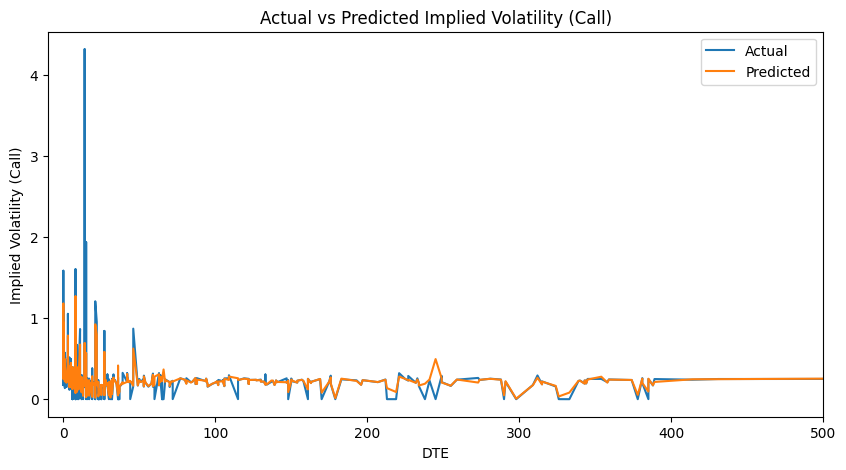

In [158]:
df_sorted = df.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["DTE"], df_sorted["C_IV"], label="Actual")
plt.plot(df_sorted["DTE"], df_sorted["Predicted_C_IV"], label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.xlim(-10, 500)
plt.legend()
plt.show()

In [159]:
put_X = df[["Quote_Time_Hours", "Underlying_Last", "DTE", "P_Volume", "P_Mid_Price", "Strike", "P_Bid_Size", "P_Ask_Size", "Strike_Distance", "Strike_Distance_PCT"]]
put_y = df["P_IV"]
put_X_train, put_X_test, put_y_train, put_y_test = train_test_split(
    put_X,
    put_y,
    test_size=0.25,
    random_state=42
)
put_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
put_rf.fit(put_X_train, put_y_train)
put_y_test_pred = put_rf.predict(put_X_test)
df["Predicted_P_IV"] = put_rf.predict(put_X)
df
print("MAE:", mean_absolute_error(put_y_test, put_y_test_pred))
print("R²:", r2_score(put_y_test, put_y_test_pred))

MAE: 0.03134523829787235
R²: 0.7776908682027723


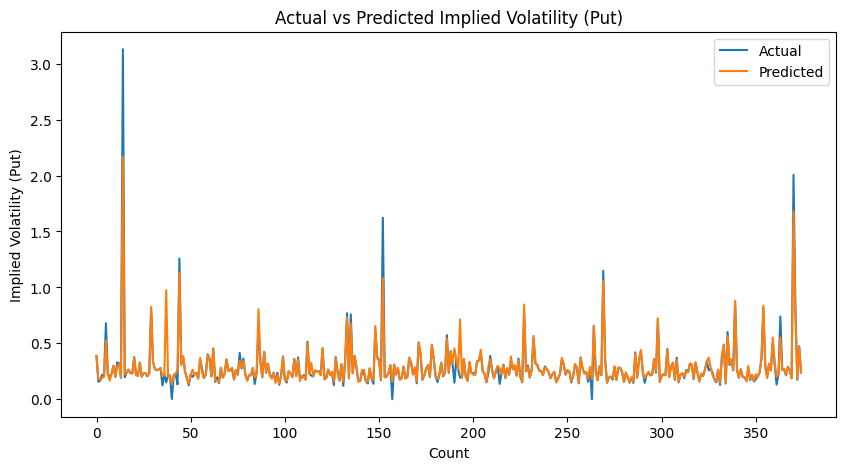

In [160]:
x = range(len(df))
plt.figure(figsize=(10, 5))
plt.plot(x, df["P_IV"], label="Actual")
plt.plot(x, df["Predicted_P_IV"], label="Predicted")
plt.xlabel("Count")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.legend()

plt.show()

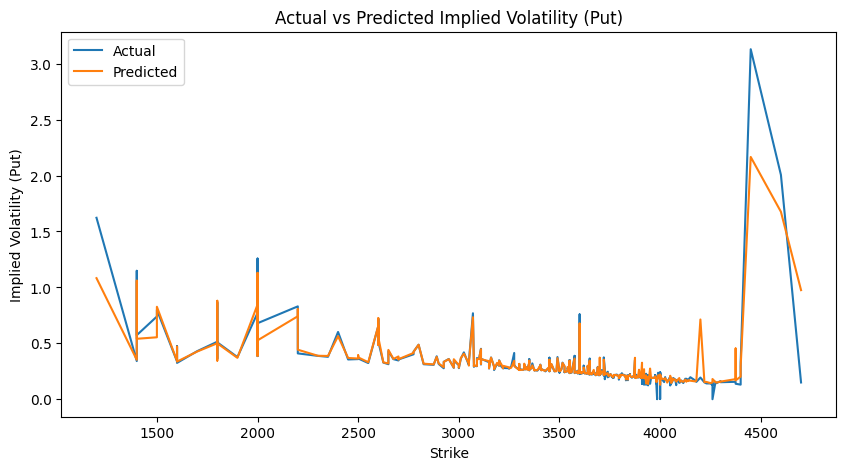

In [161]:
df_sorted = df.sort_values("Strike")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["Strike"], df_sorted["P_IV"], label="Actual")
plt.plot(df_sorted["Strike"], df_sorted["Predicted_P_IV"], label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.legend()
plt.show()

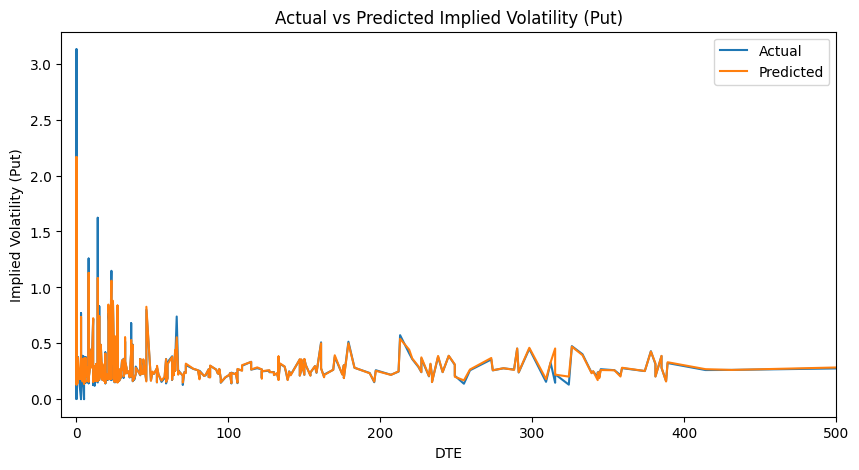

In [162]:
df_sorted = df.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["DTE"], df_sorted["P_IV"], label="Actual")
plt.plot(df_sorted["DTE"], df_sorted["Predicted_P_IV"], label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.xlim(-10, 500)
plt.legend()
plt.show()

In [163]:
df

,Quote_Time_Hours,Underlying_Last,DTE,C_IV,C_Volume,C_Last,C_Bid,C_Ask,Strike,P_Bid,P_Ask,P_Last,P_IV,P_Volume,Strike_Distance,Strike_Distance_PCT,C_Bid_Size,C_Ask_Size,P_Bid_Size,P_Ask_Size,C_Mid_Price,P_Mid_Price,Predicted_C_IV,Predicted_P_IV
128081,16.0,4070.02,385.0,0.00044,0.0,0.00,2113.2,2136.20,2000.0,11.9,12.7,13.66,0.38644,1.0,2070.0,0.509,10.0,10.0,210.0,60.0,2124.700,12.30,0.094258,0.388173
51926,16.0,3982.87,309.0,0.17471,500.0,126.60,154.0,156.00,4375.0,418.2,422.0,0.00,0.15619,0.0,392.1,0.098,37.0,39.0,50.0,50.0,155.000,420.10,0.173210,0.180423
62003,16.0,3990.40,13.0,0.16545,1.0,142.36,168.8,172.20,3830.0,5.9,6.1,6.60,0.16954,2.0,160.4,0.040,30.0,97.0,136.0,58.0,170.500,6.00,0.177738,0.177128
114524,16.0,4060.18,8.0,0.25276,2.0,156.34,184.3,188.60,3880.0,6.1,6.2,6.50,0.21995,125.0,180.2,0.044,100.0,100.0,61.0,88.0,186.450,6.15,0.209478,0.189755
143401,16.0,4077.16,381.0,0.19867,0.0,0.00,485.6,490.30,3925.0,202.5,204.9,0.00,0.20485,0.0,152.2,0.037,14.0,14.0,38.0,20.0,487.950,203.70,0.200169,0.203563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30242,16.0,3919.78,0.0,1.08178,2.0,0.35,0.0,0.05,4600.0,679.8,683.1,688.50,2.00576,1.0,680.2,0.174,0.0,114.0,44.0,37.0,0.025,681.45,0.941474,1.675752
70017,16.0,3928.85,15.0,1.93524,0.0,0.00,1726.8,1735.00,2200.0,0.0,0.1,0.00,0.83048,0.0,1728.8,0.440,3.0,47.0,0.0,354.0,1730.900,0.05,0.566053,0.742271
46258,16.0,3982.87,11.0,0.17986,5.0,95.03,192.7,196.40,3795.0,3.0,3.2,3.18,0.17573,8.0,187.9,0.047,82.0,73.0,310.0,294.0,194.550,3.10,0.189721,0.188413
97284,16.0,4019.36,326.0,0.00035,50.0,2236.72,2433.4,2452.20,1600.0,6.4,6.7,6.80,0.47496,1700.0,2419.4,0.602,10.0,10.0,238.0,311.0,2442.800,6.55,0.033429,0.470528
